# Step 8: Manuscript Figures

Russell Blessing

## Overview

This notebook builds the manuscript figures from the finalized outputs of the earlier pipeline steps. The first deliverable is **Fig. 2** — the *flooded-to-funded* pipeline funnel.

The pipeline tracks residential properties through five sequential, nested stages:

| \# | Stage | Definition | Source |
|--------|-----------------|----------------------------|-------------------|
| 1 | **flooded** | intersected the footprint of ≥ 1 of the 78 modelled events | Step 7 |
| 2 | **eligible** | flooded during an event for which its county received a PDD | Step 7 |
| 3 | **in a community** | its community (city, else county) is one where the local government assisted with the submission of ≥ 1 HMA application | Step 5 `apps_pcls` |
| 4 | **applied** | the property itself is named on an HMA application | Step 5 `apps_pcls` |
| 5 | **funded** | the property received a mitigation | Step 5 `mits_pcls` |

The funnel is computed twice: once for **all** flood-exposed residential properties, and once for the subset exposed to flooding **more than once**.

In [ ]:
library(sf)

Linking to GEOS 3.12.0, GDAL 3.11.0, PROJ 9.2.1; sf_use_s2() is TRUE


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

------------------------------------------------------------------------

## 1 Configuration

In [ ]:
out_dir <- "/proj/mhinolab/users/rbless/data/Obstacles_Output"

cfg <- list(
  # --- input files -----------------------------------------------------------
  parcels_path  = file.path(out_dir, "parcels_pri_with_floods.gpkg"),
  apps_path     = file.path(out_dir, "apps_pcls.gpkg"),
  mits_path     = file.path(out_dir, "mits_pcls.gpkg"),
  interp_path   = file.path(out_dir, "interpolated_parcels_final.csv"),

  # --- column names on the Step 7 parcel table -------------------------------
  col_parcel_id = "parcel_index",
  col_county    = "cntyfips",
  col_city      = "SITUS.CITY",
  col_flood_ct  = "flooded_any",
  col_elig_ct   = "eligible",
  col_value     = "TOTAL.VALUE.CALCULATED",
  col_lat       = "PARCEL.LEVEL.LATITUDE",
  col_lng       = "PARCEL.LEVEL.LONGITUDE",
  col_interp_flag = "interpolate",
  col_interp_val  = "prop_value_5",
  col_res_flag  = "fr_1_4.x",

  # --- behaviour -------------------------------------------------------------
  repeat_threshold = 2L
)

------------------------------------------------------------------------

## 2 Diagnostic — what is actually in the files

In [ ]:
report_cols <- function(path, want) {
  if (!file.exists(path)) { cat("  MISSING FILE:", path, "\n"); return(invisible()) }
  nm <- if (grepl("\\.gpkg$", path, ignore.case = TRUE)) {
    names(st_read(path, quiet = TRUE, query = paste0(
      "SELECT * FROM \"", tools::file_path_sans_ext(basename(path)), "\" LIMIT 0")))
  } else {
    names(read_csv(path, n_max = 0, show_col_types = FALSE))
  }
  cat("  file:", basename(path), "(", length(nm), "cols )\n")
  for (w in want) {
    hit <- w %in% nm
    cat("   ", if (hit) "[ok]  " else "[MISS]", w, "\n")
    if (!hit) {
      near <- nm[str_detect(tolower(nm), substr(tolower(w), 1, 3))]
      if (length(near)) cat("           candidates:", paste(head(near, 8), collapse = ", "), "\n")
    }
  }
}

cat("PARCELS (Step 7)\n")

PARCELS (Step 7)

  file: parcels_pri_with_floods.gpkg ( 76 cols )
    [ok]   parcel_index 
    [ok]   cntyfips 
    [ok]   SITUS.CITY 
    [ok]   flooded_any 
    [ok]   eligible 
    [ok]   fr_1_4.x 


APPLICATIONS (Step 5)

  file: apps_pcls.gpkg ( 118 cols )
    [ok]   parcel_index 
    [ok]   SITUS.CITY 
    [ok]   cntyfips 


MITIGATIONS (Step 5)

  file: mits_pcls.gpkg ( 100 cols )
    [ok]   parcel_index 
    [ok]   SITUS.CITY 
    [ok]   cntyfips 


INTERPOLATION (Step 9)

  file: interpolated_parcels_final.csv ( 78 cols )
    [ok]   parcel_index 
    [ok]   interpolate 
    [ok]   prop_value_5 

------------------------------------------------------------------------

## 3 Load finalized datasets

In [ ]:
read_any <- function(path) {
  if (grepl("\\.gpkg$", path, ignore.case = TRUE)) {
    st_read(path, quiet = TRUE) |> st_drop_geometry()
  } else {
    read_csv(path, col_types = cols(.default = col_character()))
  }
}

# Step 9 interpolation table — only the three columns we need
interp <- read_csv(
  cfg$interp_path,
  col_select = all_of(c(cfg$col_parcel_id,
                        cfg$col_interp_flag,
                        cfg$col_interp_val)),
  col_types  = cols(.default = col_character()),
  show_col_types = FALSE
) |>
  transmute(
    parcel_index = as.integer(.data[[cfg$col_parcel_id]]),
    interpolate  = suppressWarnings(as.integer(.data[[cfg$col_interp_flag]])),
    value_interp = suppressWarnings(as.numeric(.data[[cfg$col_interp_val]]))
  )

parcels <- read_any(cfg$parcels_path) |>
  transmute(
    parcel_index = as.integer(.data[[cfg$col_parcel_id]]),
    county       = as.character(.data[[cfg$col_county]]),
    city         = as.character(.data[[cfg$col_city]]),
    flood_ct     = suppressWarnings(as.numeric(.data[[cfg$col_flood_ct]])),
    elig_ct      = suppressWarnings(as.numeric(.data[[cfg$col_elig_ct]])),
    res_flag     = suppressWarnings(as.integer(.data[[cfg$col_res_flag]])),
    value_tvc    = suppressWarnings(as.numeric(.data[[cfg$col_value]])),
    lat          = suppressWarnings(as.numeric(.data[[cfg$col_lat]])),
    lng          = suppressWarnings(as.numeric(.data[[cfg$col_lng]]))
  ) |>
  left_join(interp, by = "parcel_index") |>
  mutate(
    interpolate = coalesce(interpolate, 0L),
    # prop_value_5 where this is a buyout-candidate, else CoreLogic TVC
    value       = if_else(interpolate == 1L, value_interp, value_tvc)
  ) |>
  select(-value_tvc, -value_interp) |>
  mutate(
    community = if_else(is.na(city) | str_trim(city) == "",
                        paste0("COUNTY_", county),
                        str_to_upper(str_trim(city)))
  )

cat("parcels loaded:", format(nrow(parcels), big.mark = ","), "\n")

parcels loaded: 4,216,239 

  of which fr_1_4 == 1:     3,134,408 

  of which interpolate==1:  5,456 

  sample (fr_1_4 OR interp): 3,137,520 

In [ ]:
apps <- read_any(cfg$apps_path) |>
  transmute(parcel_index = as.integer(.data[[cfg$col_parcel_id]])) |>
  filter(!is.na(parcel_index)) |>
  distinct()

mits <- read_any(cfg$mits_path) |>
  transmute(parcel_index = as.integer(.data[[cfg$col_parcel_id]])) |>
  filter(!is.na(parcel_index)) |>
  distinct()

cat("parcels with an application:", format(nrow(apps), big.mark = ","), "\n")

parcels with an application: 8,523 

parcels with a mitigation:  5,836 

------------------------------------------------------------------------

## 4 Build per-parcel pipeline flags

In [ ]:
# Set of communities where the local government assisted with >=1 HMA
# application (draft Fig. 2 stage-3 definition).
app_communities <- parcels |>
  semi_join(apps, by = "parcel_index") |>
  distinct(community) |>
  pull(community)

cat("communities with >=1 application:", length(app_communities), "\n")

communities with >=1 application: 356 

------------------------------------------------------------------------

## 5 Funnel table

In [ ]:
funnel_for <- function(df, label) {
  r <- c(sum(df$reach1), sum(df$reach2), sum(df$reach3),
         sum(df$reach4), sum(df$reach5))
  tibble(
    group        = label,
    stage_num    = 1:5,
    stage        = factor(
      c("Flooded", "Eligible", "In a community",
        "Applied", "Funded"),
      levels = c("Flooded", "Eligible", "In a community",
                 "Applied", "Funded")),
    n            = r,
    pct_of_prev  = c(NA, r[-1] / r[-5]),         # stage-to-stage retention
    pct_of_flood = r / r[1]                       # cumulative share of flooded
  )
}

funnel_all    <- funnel_for(pipeline,                     "All flood-exposed")
funnel_repeat <- funnel_for(filter(pipeline, repeat_exp), "Repeat flood-exposed")

funnel <- bind_rows(funnel_all, funnel_repeat)

funnel |>
  mutate(
    n            = format(n, big.mark = ","),
    `% of prev`  = if_else(is.na(pct_of_prev), "—",
                           paste0(round(pct_of_prev * 100, 1), "%")),
    `% of flood` = paste0(round(pct_of_flood * 100, 1), "%")
  ) |>
  select(group, stage, n, `% of prev`, `% of flood`) |>
  knitr::kable()

  group                  stage            n         \% of prev   \% of flood
  ---------------------- ---------------- --------- ------------ -------------
  All flood-exposed      Flooded          202,623   ---          100%
  All flood-exposed      Eligible         141,253   69.7%        69.7%
  All flood-exposed      In a community   132,828   94%          65.6%
  All flood-exposed      Applied          5,746     4.3%         2.8%
  All flood-exposed      Funded           3,432     59.7%        1.7%
  Repeat flood-exposed   Flooded          66,443    ---          100%
  Repeat flood-exposed   Eligible         57,671    86.8%        86.8%
  Repeat flood-exposed   In a community   53,912    93.5%        81.1%
  Repeat flood-exposed   Applied          3,705     6.9%         5.6%
  Repeat flood-exposed   Funded           2,166     58.5%        3.3%


------------------------------------------------------------------------

## 7 Fig. 3 — property value distribution by pipeline stage

Each property’s value is converted to a **percentile** — two ways. Panel A ranks each property against the entire `fr_1_4` study-area sample (one big pool). Panel B ranks each property only against the other `fr_1_4` properties that fall in the same 0.01° EIF grid cell. Both panels show the density of those percentiles at each pipeline stage, with a vertical line at the stage median.

### 7.1 Build the percentile sample

In [ ]:
# Attach value + lat/lng to the residential pipeline (fr_1_4) parcels.
# Drop parcels with missing or non-positive value and missing coordinates.
value_df <- pipeline |>
  filter(!is.na(value), value > 0, !is.na(lat), !is.na(lng)) |>
  mutate(
    eif_cell = paste0(floor(lat * 100), "_", floor(lng * 100)),
    pct_A = dplyr::percent_rank(value) * 100
  ) |>
  group_by(eif_cell) |>
  mutate(
    cell_n = dplyr::n(),
    pct_B  = if_else(cell_n >= 5, dplyr::percent_rank(value) * 100, NA_real_)
  ) |>
  ungroup()

cat("sample parcels (fr_1_4 OR interp, w/ value + coords):",
    format(nrow(value_df), big.mark = ","), "\n")

sample parcels (fr_1_4 OR interp, w/ value + coords): 2,417,645 

distinct EIF cells: 62,490 

parcels with valid Panel B percentile: 2,382,269 

### 7.2 Long-format stage data

In [ ]:
stage_order <- c("Flooded", "Eligible", "In a community",
                 "Applied", "Funded")
 
# Cumulative reach: each stage is a (nested) subset of the previous.
fig3_long <- bind_rows(
  value_df |> filter(reach1) |> mutate(stage = "Flooded"),
  value_df |> filter(reach2) |> mutate(stage = "Eligible"),
  value_df |> filter(reach3) |> mutate(stage = "In a community"),
  value_df |> filter(reach4) |> mutate(stage = "Applied"),
  value_df |> filter(reach5) |> mutate(stage = "Funded")
) |>
  # Reverse factor levels so Flooded sits at the top of the ridgeline.
  mutate(stage = factor(stage, levels = rev(stage_order)))

### 7.4 Plot

In [ ]:
panel_labels <- c(
  pct_A = "Property Value Percentile",
  pct_B = "Property Value Percentile within EIF Grid Cell (n > 5)"
)

fig3_panel <- fig3_long |>
  select(stage, pct_A, pct_B) |>
  tidyr::pivot_longer(c(pct_A, pct_B),
                      names_to = "panel", values_to = "pct") |>
  filter(!is.na(pct)) |>
  mutate(
    stage = factor(as.character(stage), levels = stage_order),
    panel = factor(recode(panel, !!!panel_labels),
                   levels = unname(panel_labels))
  )

stage_colors <- c(
  "Flooded"        = "#0072B2",
  "Eligible"       = "#009E73",
  "In a community" = "#E69F00",
  "Applied"        = "#D55E00",
  "Funded"         = "#CC79A7"
)
stage_linetypes <- c(
  "Flooded"        = "solid",
  "Eligible"       = "dashed",
  "In a community" = "dotted",
  "Applied"        = "dotdash",
  "Funded"         = "longdash"
)

In [ ]:
# Option A: Density curves
fig3_median_lines <- fig3_panel |>
  group_by(panel, stage) |>
  summarise(median_pct = median(pct), .groups = "drop")

y_ceil   <- 0.035
y_breaks <- seq(0, y_ceil, by = 0.005)

fig3 <- ggplot(fig3_panel, aes(x = pct, colour = stage, linetype = stage)) +
  stat_density(
    geom = "line", position = "identity",
    adjust = 1.5, linewidth = 0.85, trim = TRUE
  ) +
  geom_vline(
    data = fig3_median_lines,
    aes(xintercept = median_pct, colour = stage, linetype = stage),
    linewidth = 0.55, alpha = 0.9, show.legend = FALSE
  ) +
  facet_wrap(~ panel, ncol = 2, axes = "all") +
  coord_cartesian(xlim = c(0, 100), ylim = c(0, y_ceil), expand = FALSE) +
  scale_x_continuous(
    breaks = seq(0, 100, 20),
    labels = function(x) paste0(x, "%"),
    expand = expansion(add = 3)
  ) +
  scale_y_continuous(
    breaks = y_breaks,
    labels = scales::label_number(accuracy = 0.001)
  ) +
  scale_colour_manual(values = stage_colors, name = NULL) +
  scale_linetype_manual(values = stage_linetypes, name = NULL) +
  guides(
    colour   = guide_legend(
      nrow = 1,
      override.aes = list(linewidth = 1, linetype = unname(stage_linetypes))
    ),
    linetype = "none"
  ) +
  labs(
    title = "Fig. 3  Property value distribution by pipeline stage",
    x = "Percentile", y = "Density"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    axis.line         = element_line(colour = "grey30", linewidth = 0.5),
    axis.ticks        = element_line(colour = "grey30", linewidth = 0.4),
    axis.ticks.length = unit(3, "pt"),
    axis.text         = element_text(colour = "grey20"),
    axis.title        = element_text(colour = "grey20"),
    axis.text.y       = element_text(colour = "grey20"),
    axis.title.y      = element_text(colour = "grey20"),
    strip.text        = element_text(face = "bold", hjust = 0, colour = "grey10"),
    strip.background  = element_blank(),
    legend.position   = "bottom",
    legend.key        = element_blank(),
    legend.key.width  = unit(2, "cm"),
    legend.key.height = unit(0.4, "lines"),
    panel.grid.major  = element_blank(),
    panel.grid.minor  = element_blank(),
    panel.spacing.x   = unit(1.5, "cm"),
    plot.margin       = margin(10, 14, 10, 10)
  )

fig3

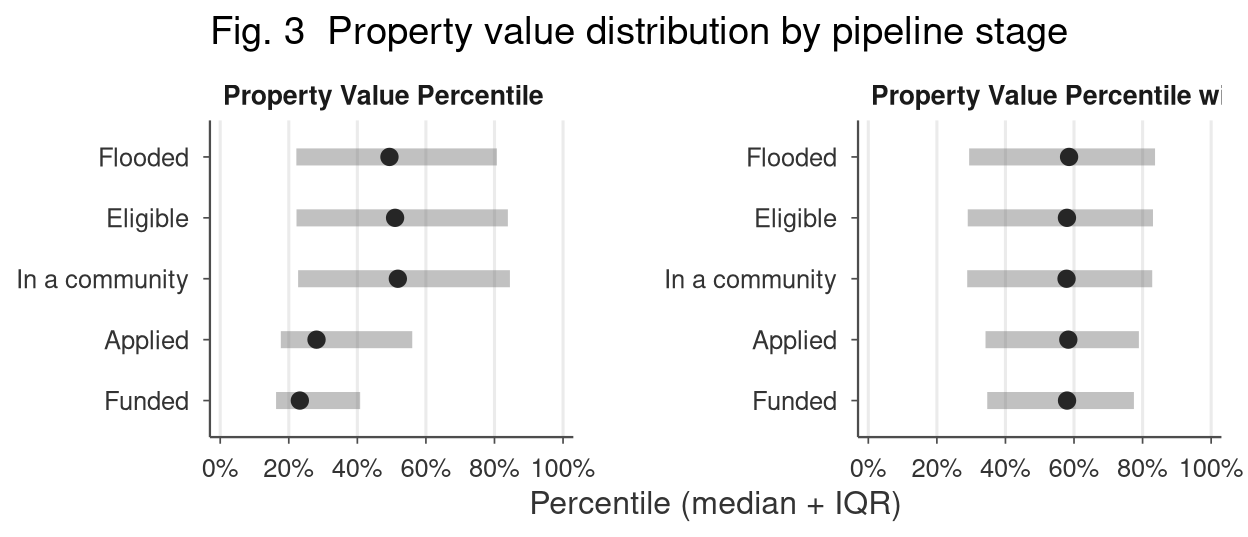

In [ ]:
# Option B: Median + IQR dot-segment — grayscale, publication dimensions
fig3_ci <- fig3_panel |>
  group_by(panel, stage) |>
  summarise(
    median = median(pct),
    lo     = quantile(pct, 0.25),
    hi     = quantile(pct, 0.75),
    .groups = "drop"
  ) |>
  mutate(stage = factor(stage, levels = rev(stage_order)))

fig3 <- ggplot(fig3_ci, aes(x = median, y = stage)) +
  geom_segment(
    aes(x = lo, xend = hi, yend = stage),
    colour = "grey40", linewidth = 3, alpha = 0.4
  ) +
  geom_point(colour = "grey15", size = 2.5) +
  facet_wrap(~ panel, ncol = 2, axes = "all") +
  scale_x_continuous(
    limits = c(0, 100),
    breaks = seq(0, 100, 20),
    labels = function(x) paste0(x, "%"),
    expand = expansion(add = 3)
  ) +
  labs(
    title = "Fig. 3  Property value distribution by pipeline stage",
    x = "Percentile (median + IQR)", y = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    axis.line          = element_line(colour = "grey30", linewidth = 0.4),
    axis.ticks         = element_line(colour = "grey30", linewidth = 0.3),
    axis.ticks.length  = unit(2.5, "pt"),
    axis.text          = element_text(colour = "grey20"),
    axis.title         = element_text(colour = "grey20"),
    strip.text         = element_text(face = "bold", hjust = 0, colour = "grey10", size = 10),
    strip.background   = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor   = element_blank(),
    panel.spacing.x    = unit(1.2, "cm"),
    plot.margin        = margin(6, 10, 6, 6)
  )

fig3

In [ ]:
dir.create(file.path(getwd(), "figures"), showWarnings = FALSE)
ggsave(
  filename = file.path(getwd(), "figures", "fig3.png"),
  plot     = fig3,
  width    = 6.5,
  height   = 2.8,
  units    = "in",
  dpi      = 300
)
write_csv(fig3_ci, file.path(getwd(), "figures", "fig3_ci.csv"))